# Time Series_ London Air Quality Data- NO2 & PM25 levels

In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
from prophet.make_holidays import make_holidays_df

# Load air quality dataset
air_quality_data = pd.read_csv('london_air_quality_2010_2023_top5_sites.csv',parse_dates=['datetime'])


# Filter for Kensington and keep 'datetime', target ('no2_level'), and regressor ('pm25_level')
kensington_no2_pm25 = air_quality_data[
                     air_quality_data["SiteName"] == "Kensington and Chelsea - North Ken"][["datetime", "no2_level","pm25_level"]]


# Resampliing as daily & Interpolate missing values for target and regressor
kensington_no2_pm25: pd.DataFrame = kensington_no2_pm25.set_index("datetime")
kensington_no2_pm25["no2_level"] = kensington_no2_pm25["no2_level"].interpolate(method="time")
kensington_no2_pm25 = (
    kensington_no2_pm25
    .resample("D")
    .mean().reset_index()
)
kensington_no2_pm25["pm25_level"] = kensington_no2_pm25["pm25_level"].bfill() .interpolate(method='linear')

# Rename to Prophet's expected column names ('ds' and 'y')
kensington_no2_pm25: pd.DataFrame = kensington_no2_pm25.rename(columns={'datetime': 'ds', 'no2_level': 'y'})


# Time-Series Train-Test Split (90% Train, 10% Test)
split_idx = int(len(kensington_no2_pm25) * 0.90)
train_df = kensington_no2_pm25.iloc[:split_idx].copy()
test_df = kensington_no2_pm25.iloc[split_idx:].copy()


# Fetch official UK / England Bank Holidays & additional events
year_list: list[int] = list(range(2010, 2024))
uk_holidays = make_holidays_df(year_list=year_list, country="UK", province="ENG")
bonfire_nights = pd.DataFrame({
  'holiday': 'bonfire_night',
  'ds': pd.to_datetime(['2010-11-05', '2011-11-05','2012-11-05', '2013-11-05','2014-11-05', '2015-11-05','2016-11-05', 
                        '2017-11-05','2018-11-05', '2019-11-05','2020-11-05', '2021-11-05', '2022-11-05', '2023-11-05' ]),
  'lower_window': 0,
  'upper_window': 1, # Captures smoke lingering overnight
})
    ##  Combine both holiday sources into a single DataFrame
lon_holidays = (
    pd.concat([uk_holidays, bonfire_nights], ignore_index=True)
    .sort_values("ds")
    .reset_index(drop=True)
)


# Initialize & Fit Prophet (on Train Set Only)
model_uk: Prophet = Prophet(
                            yearly_seasonality=True,
                            weekly_seasonality=True,
                            daily_seasonality=False,
                            changepoint_prior_scale=0.05,# controls trend flexibility
                            seasonality_mode= 'additive',
                            holidays=lon_holidays
)

# Add regressor
model_uk.add_regressor('pm25_level')
model_uk.fit(train_df)  



# Predicting on combined train + test data
future_uk: pd.DataFrame = kensington_no2_pm25[['ds', 'pm25_level']].copy()
forecast_uk: pd.DataFrame = model_uk.predict(future_uk)


10:31:30 - cmdstanpy - INFO - Chain [1] start processing
10:31:31 - cmdstanpy - INFO - Chain [1] done processing


### Plotting the forecast

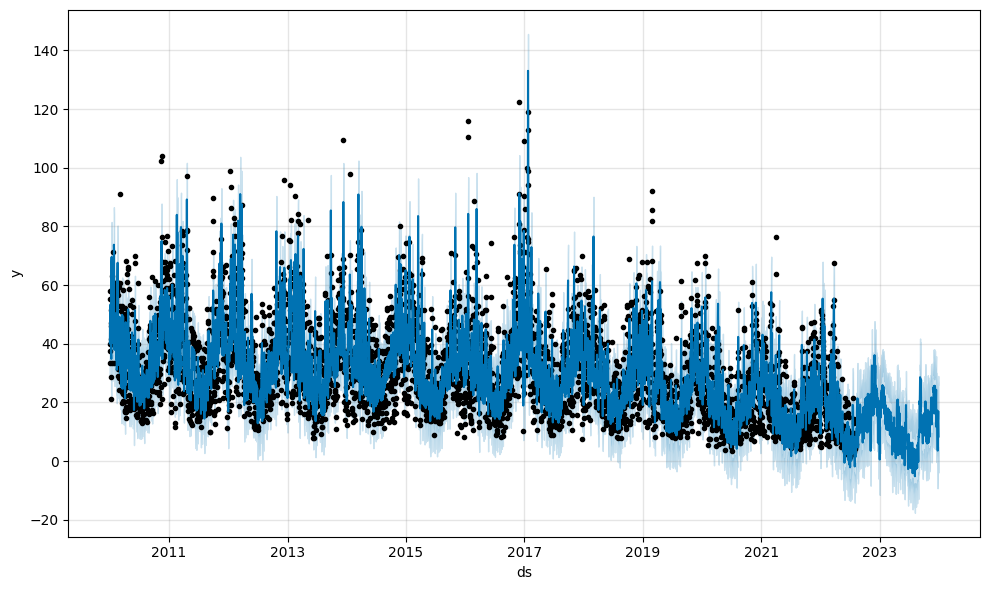

In [2]:
# Plot the forecast
model_uk.plot(forecast_uk);

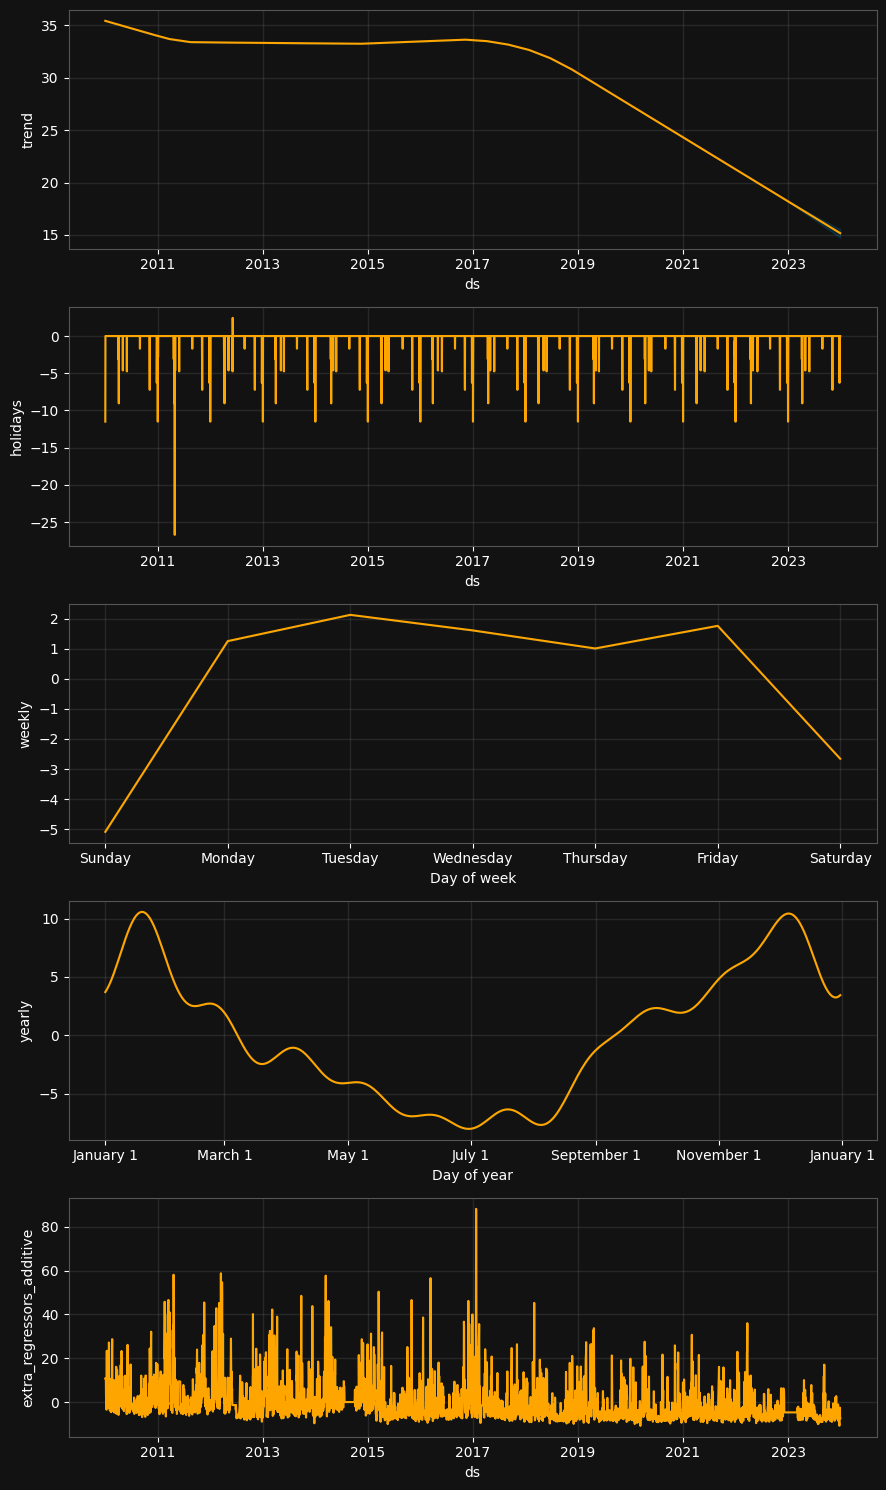

In [3]:
import matplotlib.pyplot as plt
fig3 = model_uk.plot_components(forecast_uk)

# Dark background
fig3.patch.set_facecolor("#121212")

for ax in fig3.axes:
    ax.set_facecolor("#121212")
    ax.tick_params(colors="white")
    
    # Change title and axis labels
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    
    # Change spines
    for spine in ax.spines.values():
        spine.set_color("#555555")

# Orange lines
for ax in fig3.axes:
    if ax.lines:
        ax.lines[0].set_color("orange")

plt.show()

### Evaulating performance

In [4]:

# 1.Merge forecast and actuals on 'ds' to guarantee exact row alignment
eval_df_uk: pd.DataFrame = pd.merge(
    test_df[["ds", "y"]],
    forecast_uk[["ds", "yhat"]],
    on="ds",
    how="inner",
).dropna()

# 2. Extract arrays
y_true: np.ndarray = eval_df_uk["y"].values
y_pred: np.ndarray = eval_df_uk["yhat"].values

# 3. Calculate MAE & RMSE
mae: float = np.mean(np.abs(y_true - y_pred))
rmse: float = np.sqrt(np.mean((y_true - y_pred) ** 2))


# 4. Calculate MAPE safely (avoiding zero division)
eps = 1e-8  # Small epsilon to prevent division by zero
mape: float = np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100


print(f"Evaluation Metrics with Holiday:")
print(f"\t Mean Absolute Error (MAE) with holidays: {mae:.2f}")
print(f"\t Root Mean Squared Error (RMSE)with holidays: {rmse:.2f}")
print(f"\t Mean Absolute Percentage Error (MAPE)with holidays: {mape:.2f}%")


Evaluation Metrics with Holiday:
	 Mean Absolute Error (MAE) with holidays: 7.05
	 Root Mean Squared Error (RMSE)with holidays: 9.84
	 Mean Absolute Percentage Error (MAPE)with holidays: 52.37%
